In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import NeuralPosteriorEstimator
from src.data.reinfection import AoN, Win, PPI, InH, TwoVi, Mut, BaseReinfectionModel
mps_device = torch.device("mps")
import pandas as pd

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a
T = 59
J = 100

#### Objective 

Fit each of the six candidate models to the observed data with NPE. Visualize and analyze the predicted incidence, separate from a noisy observation model.

Can also look into the dynamics of reinfection.

If I'm to redo this, make sure to scale all extinction probability survival plots to the same y-scale, would make them easier to compare visually.

# 0. Base SEIR Model

In [4]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)

In [5]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True,
                                   mode="estimation", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 29.0s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 35.1 K | train
-------------------------------------------
35.1 K    Trainable params
0         Non-trainable params
35.1 K    Total params
0.140     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

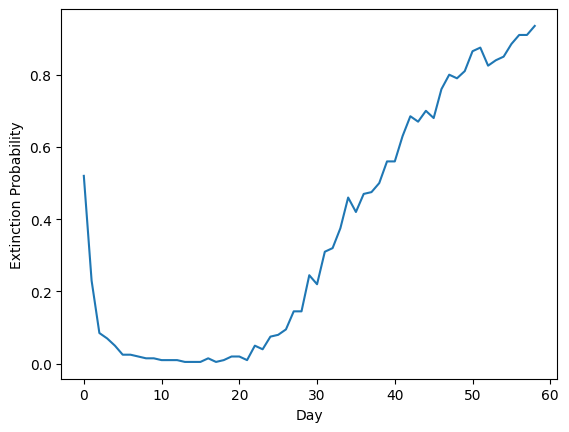

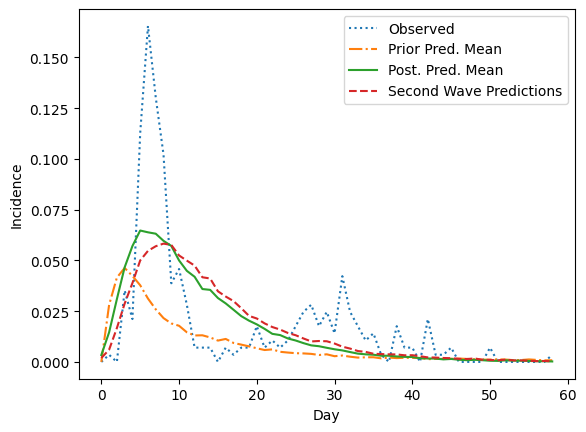

In [18]:
dataset = base_dataset
tag = "base"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
# plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# I. 2Vi
Two-virus

In [19]:
beta_1_prior = torch.distributions.Exponential(rate=0.3)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
beta_2_prior = torch.distributions.Exponential(rate=0.15)

In [20]:
twovi_dataset = TwoVi(init_I1=3, init_I2=1, init_S=277, beta_1=beta_1_prior, epsilon=epsilon_prior,
                     nu=nu_prior, rho=rho_prior, gamma=gamma_prior, beta_2=beta_2_prior, notebook=True,
                     n_sample=N)
start = time.time()
twovi_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 247.0s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

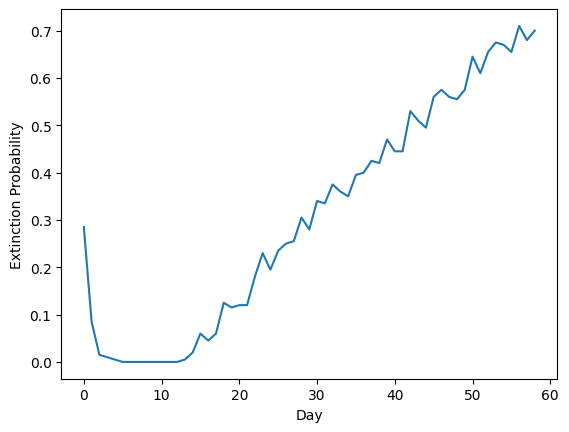

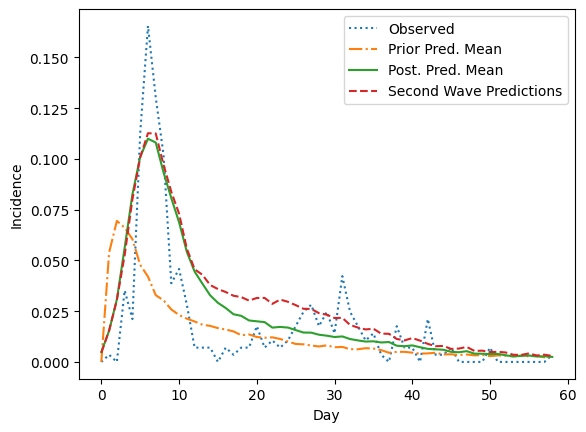

In [21]:
dataset = twovi_dataset
tag = "2vi"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="PPM, ", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# II. Mut

In [22]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.7)
mu_prior = torch.distributions.Uniform(low=0, high=1)

In [24]:
mut_dataset = Mut(init_I=1, init_S=278, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    sigma=sigma_prior, mu=mu_prior, notebook=True)
start = time.time()
mut_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 165.3s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 37.4 K | train
-------------------------------------------
37.4 K    Trainable params
0         Non-trainable params
37.4 K    Total params
0.150     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

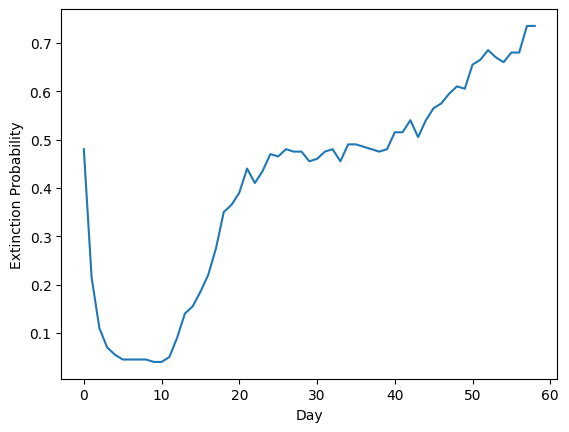

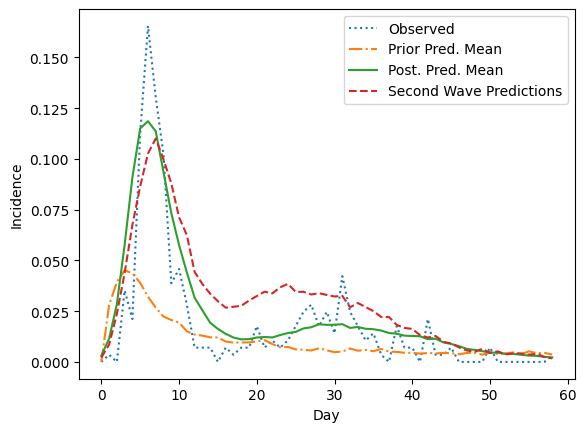

In [25]:
dataset = mut_dataset
tag = "mut"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# III. AoN
All-or-nothing

In [26]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [27]:
aon_dataset = AoN(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    alpha=alpha_prior, notebook=True)
start = time.time()
aon_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 95.1s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

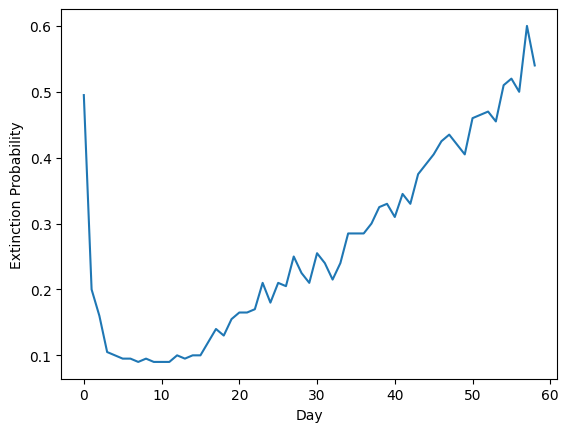

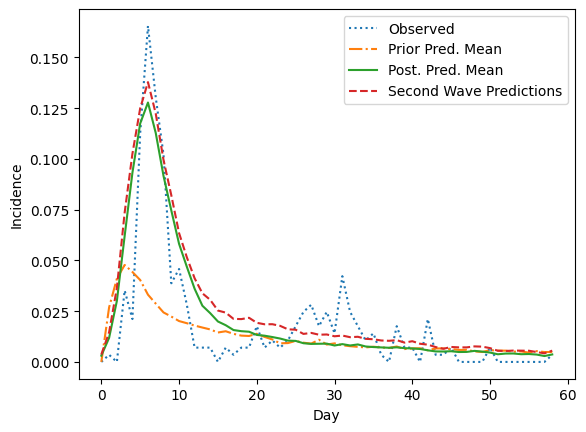

In [28]:
dataset = aon_dataset
tag = "aon"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# IV. PPI
Partial Protective Immunity

In [29]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.7)

In [30]:
ppi_dataset = PPI(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    sigma=sigma_prior, notebook=True)
start = time.time()
ppi_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 153.2s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

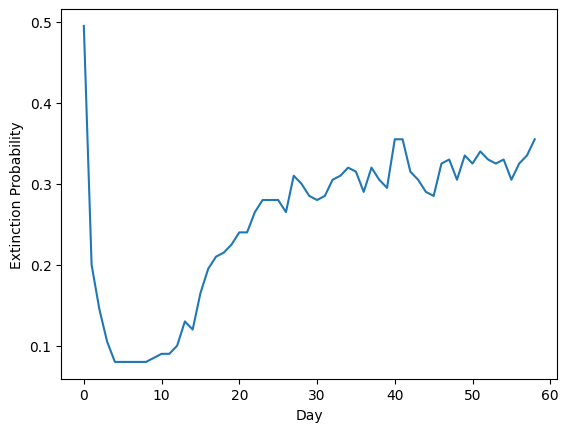

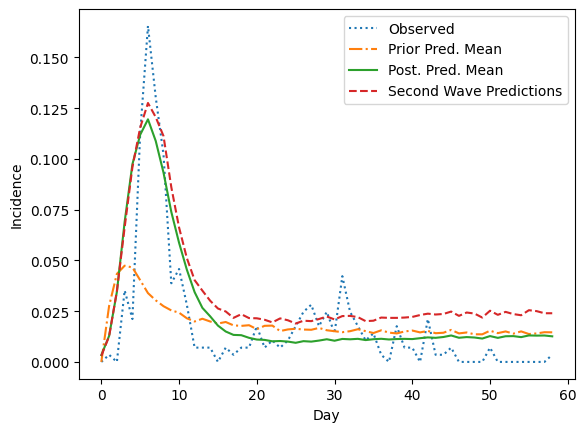

In [31]:
dataset = ppi_dataset
tag = "ppi"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# V. InH
In-host

In [32]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=12)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [33]:
inh_dataset = InH(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    alpha=alpha_prior, notebook=True)
start = time.time()
inh_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 93.1s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

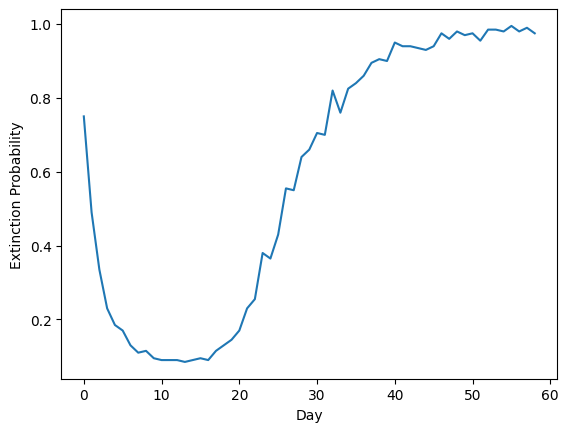

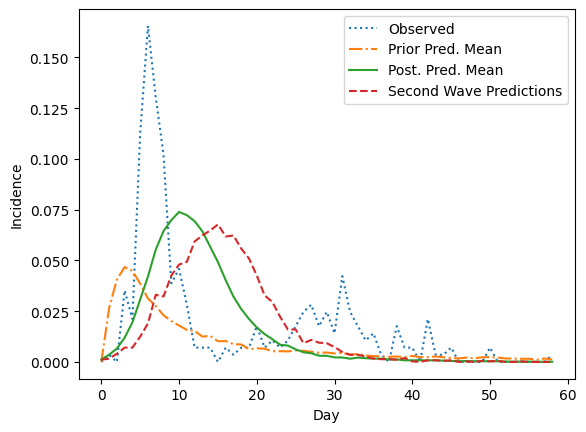

In [34]:
dataset = inh_dataset
tag = "inh"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()

# VI. Win
Window-of-reinfection

In [35]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
tau_prior = torch.distributions.Exponential(rate=4)

In [36]:
win_dataset = Win(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    tau=tau_prior, notebook=True)
start = time.time()
win_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 150.0s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

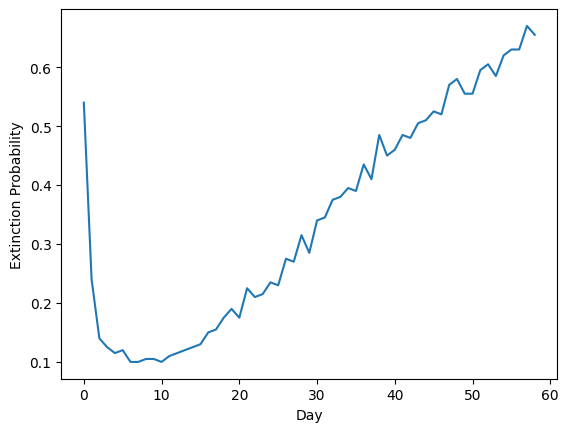

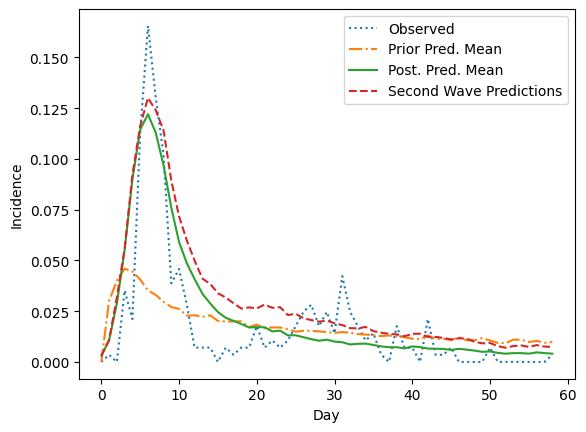

In [37]:
dataset = win_dataset
tag = "win"
x_o = dataset.get_observed_data()[0]

params = list(dataset.parameters.keys())
# _ = summarize_sample(prior_sample, params, "Prior")

# construct data loaders
train_data, val_data = random_split(dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)


# train NPE
optim = partial(torch.optim.AdamW, lr=0.0005)
d_theta = dataset.theta.shape[1]
model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

J = 200

# fit to data and sample from the posterior
torch.manual_seed(1)
posterior_sample_transformed = model.sample(J, x_o)
posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)

if type(x_o) is torch.Tensor:
    x_o = x_o.numpy()
ppd = np.empty((J, 59))
for j in range(J):
    z = posterior_sample[j]
    ppd[j] = dataset.simulate(z, seed=j*4, observed=False)


plt.plot((ppd == 0).mean(0))
plt.xlabel("Day")
plt.ylabel("Extinction Probability")
plt.savefig(f"figures/extinction_probability_{tag}.png")
plt.show()


# what trajectories don't extinguish between days 10-31?
extinct = np.zeros(J)
for j in range(J):
    x = ppd[j]
    if (x[9:31] == 0).any():
        extinct[j] = 1
        continue
no_extinction = ppd[(1 - extinct).astype(bool)].mean(0)

plt.plot(x_o, label="Observed",  linestyle=":")
plt.plot(dataset.data[:200].mean(0), label="Prior Pred. Mean", linestyle="-.")
plt.plot(ppd.mean(0), label="Post. Pred. Mean", linestyle="-")
plt.plot(no_extinction, label="Second Wave Predictions", linestyle="--") # think of a better label?
plt.xlabel("Day")
plt.ylabel("Incidence")
plt.legend()
plt.savefig(f"figures/prediction_comparison_{tag}.png")
plt.show()